In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


In [2]:
file_ds_levels='monthlyaveragedpressurelevelthing.grib'
file_ds_sp=r'C:\Users\Darkrai\Projects\iitk proj\sp_tcwv\data.grib'

ds_levels=xr.open_dataset(file_ds_levels,engine='cfgrib')
ds_sp=xr.open_dataset(file_ds_sp,engine='cfgrib')

Ignoring index file 'C:\\Users\\Darkrai\\Projects\\iitk proj\\sp_tcwv\\data.grib.5b7b6.idx' incompatible with GRIB file


In [3]:
selected_ds_lev=ds_levels.sel(latitude=26.49,longitude=80.24,method='nearest')
selected_ds_sp=ds_sp.sel(latitude=26.49,longitude=80.24,method='nearest')

In [4]:
selected_ds_sp

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 47728)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 382kB 2021-01-01 ... 2026-06-12T15:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    float64 8B 26.5
    longitude   float64 8B 80.25
    valid_time  (time) datetime64[ns] 382kB ...
Data variables:
    sp          (time) float32 191kB ...
    tcwv        (time) float32 191kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-29T14:13 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
print(selected_ds_lev.latitude.values)
print(selected_ds_lev.longitude.values)

26.5
80.25


In [6]:
time = selected_ds_lev['time'].to_numpy()
z=selected_ds_lev['z'].to_numpy()
q=selected_ds_lev['q'].to_numpy()


In [7]:
sp=selected_ds_sp['sp'].to_numpy()
time_singles=selected_ds_sp['time'].to_numpy()

In [8]:
sp_monthly = (
    selected_ds_sp["sp"]
    .resample(time="MS")
    .mean()
)
sp_avg = (
    sp_monthly
    .sel(time=selected_ds_lev.time, method="nearest")
    .values
)

In [9]:
sp_avg

array([100082.06 , 100082.06 , 100082.06 , ...,  99478.266,  99131.02 ,
        98873.52 ], shape=(1037,), dtype=float32)

In [10]:
print(q.shape)
print(sp_avg.shape)
print(selected_ds_lev.isobaricInhPa.values)

(1037, 37)
(1037,)
[1000.  975.  950.  925.  900.  875.  850.  825.  800.  775.  750.  700.
  650.  600.  550.  500.  450.  400.  350.  300.  250.  225.  200.  175.
  150.  125.  100.   70.   50.   30.   20.   10.    7.    5.    3.    2.
    1.]


In [11]:
from scipy.interpolate import interp1d

levels = selected_ds_lev["isobaricInhPa"].values * 100

pwv = np.zeros(len(time))

for t in range(len(time)):

    q_profile = q[t]
    ps = sp_avg[t]

    f = interp1d(
        levels[::-1],
        q_profile[::-1],
        kind='linear',
        fill_value='extrapolate'
    )

    q_surface = float(f(ps))

    valid = levels < ps

    p_use = np.concatenate(([ps], levels[valid]))
    q_use = np.concatenate(([q_surface], q_profile[valid]))

    pwv[t] = abs(np.trapz(q_use, p_use)) / 9.81

C:\Users\Darkrai\AppData\Local\Temp\ipykernel_20156\463063998.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pwv[t] = abs(np.trapz(q_use, p_use)) / 9.81


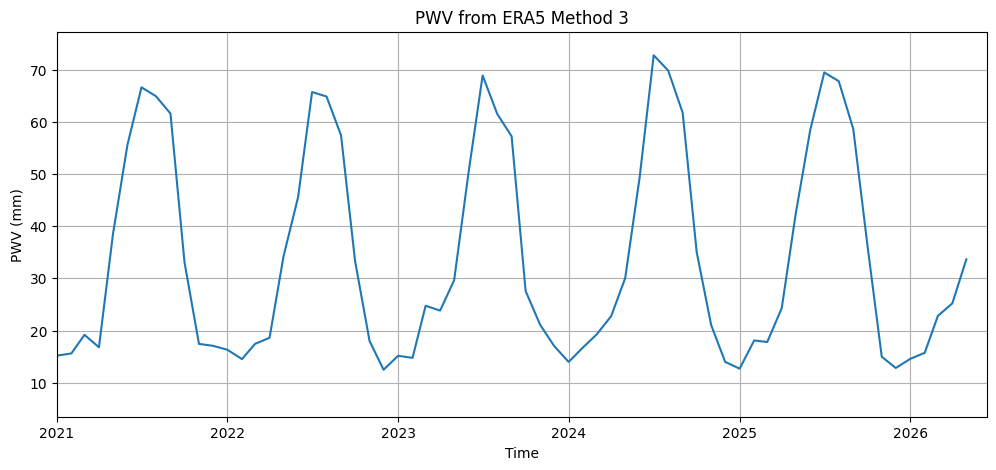

In [12]:
import numpy as np

plt.figure(figsize=(12,5))

plt.plot(time, pwv)

plt.xlim(
    np.datetime64('2021-01-01'),
    np.datetime64('2026-06-14')
)

plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("PWV from ERA5 Method 3")
plt.grid(True)

plt.show()

In [13]:
tcwv=selected_ds_sp['tcwv'].to_numpy()

In [14]:
tcwv_monthly = (
    selected_ds_sp["sp"]
    .resample(time="MS")
    .mean()
)
tcwv_avg = (
    selected_ds_sp["tcwv"]
    .resample(time="MS")
    .mean()
    .sel(time=selected_ds_lev.time, method="nearest")
    .values
)

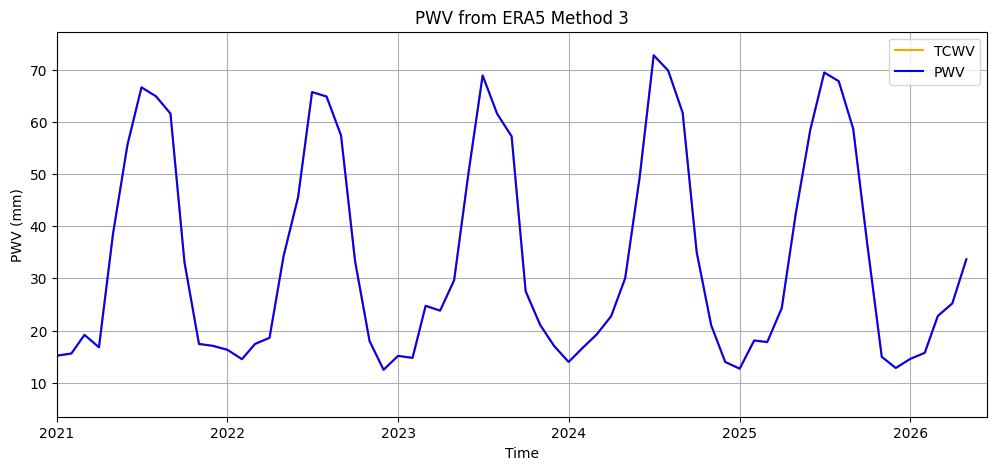

In [15]:
import numpy as np

plt.figure(figsize=(12,5))
plt.plot(time, tcwv_avg, label='TCWV', color='orange')
plt.plot(time, pwv,label='PWV', color='blue')

plt.xlim(
    np.datetime64('2021-01-01'),
    np.datetime64('2026-06-14')
)

plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("PWV from ERA5 Method 3")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
tcwv_avg.shape

(1037,)

In [17]:
monthly_temp_file=r"C:\Users\Darkrai\Projects\iitk proj\2mtemp_etc\data.grib"
ds_temp=xr.open_dataset(monthly_temp_file,engine='cfgrib')



In [18]:
ds_temp

<xarray.Dataset> Size: 111MB
Dimensions:     (time: 47733, latitude: 17, longitude: 17)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 382kB 2021-01-01 ... 2026-06-12T20:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 136B 28.5 28.25 28.0 ... 25.0 24.75 24.5
  * longitude   (longitude) float64 136B 78.5 78.75 79.0 ... 82.0 82.25 82.5
    valid_time  (time) datetime64[ns] 382kB ...
Data variables:
    t2m         (time, latitude, longitude) float32 55MB ...
    tco3        (time, latitude, longitude) float32 55MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-29T14:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [19]:
selected_ds_temp=ds_temp.sel(latitude=26.49,longitude=80.24,method='nearest')
selected_ds_temp

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 47733)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 382kB 2021-01-01 ... 2026-06-12T20:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    float64 8B 26.5
    longitude   float64 8B 80.25
    valid_time  (time) datetime64[ns] 382kB ...
Data variables:
    t2m         (time) float32 191kB ...
    tco3        (time) float32 191kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-29T14:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
temp=selected_ds_temp['t2m'].to_numpy()
temp=temp[:-5]
temp.shape

(47728,)

In [21]:
temp_monthly = (
    selected_ds_temp["t2m"]
    .groupby("time.month")
)

temp_avg = (
    selected_ds_temp["t2m"]
    .resample(time="MS")
    .mean()
    .sel(time=selected_ds_lev.time, method="nearest")
    .values
)

(np.float64(18628.0), np.float64(20618.0))

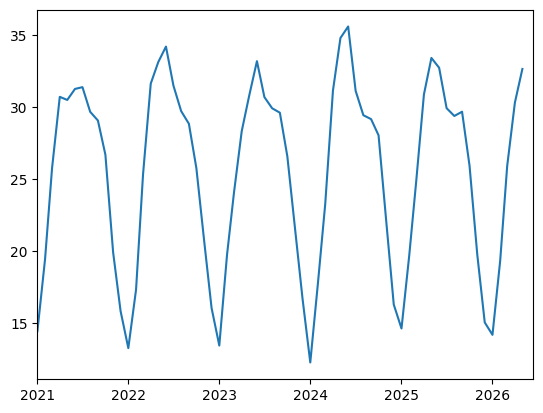

In [22]:
plt.plot(time,temp_avg-273.15)
plt.xlim(
    np.datetime64('2021-01-01'),
    np.datetime64('2026-06-14')
)

In [23]:
to3=selected_ds_temp['tco3'].to_numpy()
to3=to3[:-5]
to3.shape

(47728,)

In [24]:
to3_monthly = (
    selected_ds_temp["tco3"]
    .groupby("time.month")
)
to3_avg = (
    selected_ds_temp["tco3"]
    .resample(time="MS")
    .mean()
    .sel(time=selected_ds_lev.time, method="nearest")
    .values
)

In [25]:
to3_avg

array([0.0054573 , 0.0054573 , 0.0054573 , ..., 0.00629699, 0.00638232,
       0.00645147], shape=(1037,), dtype=float32)

In [26]:
am_executable=r"C:\Program Files\Smithsonian Institution\am-14.0\am.exe"

In [27]:
import numpy as np

mask = time >= np.datetime64('2021-01-01')

time = time[mask]
sp_avg = sp_avg[mask]
tcwv_avg = tcwv_avg[mask]
temp_avg = temp_avg[mask]
to3_avg = to3_avg[mask]
pwv = pwv[mask]

In [28]:
time.shape

(65,)

In [29]:
print(time[0])
print(time[-1])

print(time.shape)
print(sp_avg.shape)
print(tcwv_avg.shape)
print(temp_avg.shape)
print(to3_avg.shape)
print(pwv.shape)

2021-01-01T00:00:00.000000000
2026-05-01T00:00:00.000000000
(65,)
(65,)
(65,)
(65,)
(65,)
(65,)


In [1]:
#tcwv_avg and temp_avg and sp_avg
import subprocess
import os
file_amc='first_amcfile.amc'
output_file='am_output.dat'
for i in range (len(sp_avg)):
    with open(file_amc, "w") as f:
        
        f.write("f 0 GHz  1000 GHz  0.01 GHz\n\n")
        f.write("T0 2.7 K\n\n")
        f.write("layer\n")
        f.write(f"Pbase {sp_avg[i]/100:.8f} mbar\n")
        f.write(f"Tbase {temp_avg[i]:.8f} K\n")
        f.write(f"column dry_air hydrostatic\n")
        f.write(f"column H2O {tcwv_avg[i]:.8f} mm_pwv\n")
        # f.write(f"column O3 {to3_avg[i]:.8f} kg*m-2\n")
        f.flush()
    with open(file_amc, "r") as in_file:
        result = subprocess.run(
            [am_executable, "stdin"], 
            stdin=in_file, 
            stdout=subprocess.PIPE, 
            stderr=subprocess.PIPE, 
            text=True, 
            check=False
        )   
    # the stdout will get 3 columns of numbers save the first column as normal GHz column 2nd and third will keep changing in each iteration so save them properly so I can just plot them in future
    output_lines = result.stdout.strip().split("\n")
    data_lines = [line.split() for line in output_lines if line and not line.startswith("?")]
    
    if data_lines:
        spectral_matrix = np.array(data_lines, dtype=float)
        
        if i == 0:
            freq_axis = spectral_matrix[:, 0]
            np.save("frequency_axis_ghz.npy", freq_axis)
            
            num_frequencies = len(freq_axis)
            total_iterations = len(sp_avg)
            transmittance_history = np.zeros((num_frequencies, total_iterations))
            brightness_temp_history = np.zeros((num_frequencies, total_iterations))
        
        transmittance_history[:, i] = spectral_matrix[:, 1]
        brightness_temp_history[:, i] = spectral_matrix[:, 2]

np.save("transmittance_history_matrix.npy", transmittance_history)
np.save("brightness_temp_history_matrix.npy", brightness_temp_history)
    
        

NameError: name 'sp_avg' is not defined

Text(0, 0.5, 'Transmittance')

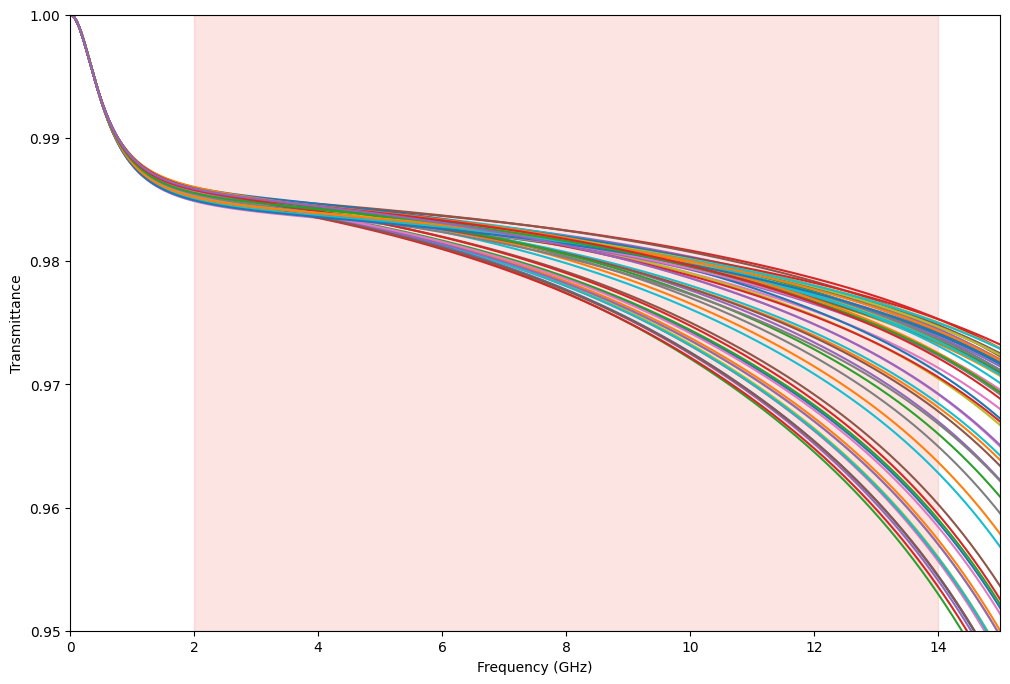

In [46]:
transmittance=np.load("transmittance_history_matrix.npy")
brightness=np.load("brightness_temp_history_matrix.npy")
frequency_axis=np.load("frequency_axis_ghz.npy")
#plot
plt.figure(figsize=(12,8))
plt.axvspan(2, 14, color="#e74c3c", alpha=0.15, label="VGOS Broadband Track (2-14 GHz)")
plt.plot(frequency_axis,transmittance[:,:])
plt.xlim(0,15)
plt.ylim(0.95,1)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmittance")

(0.0, 20.0)

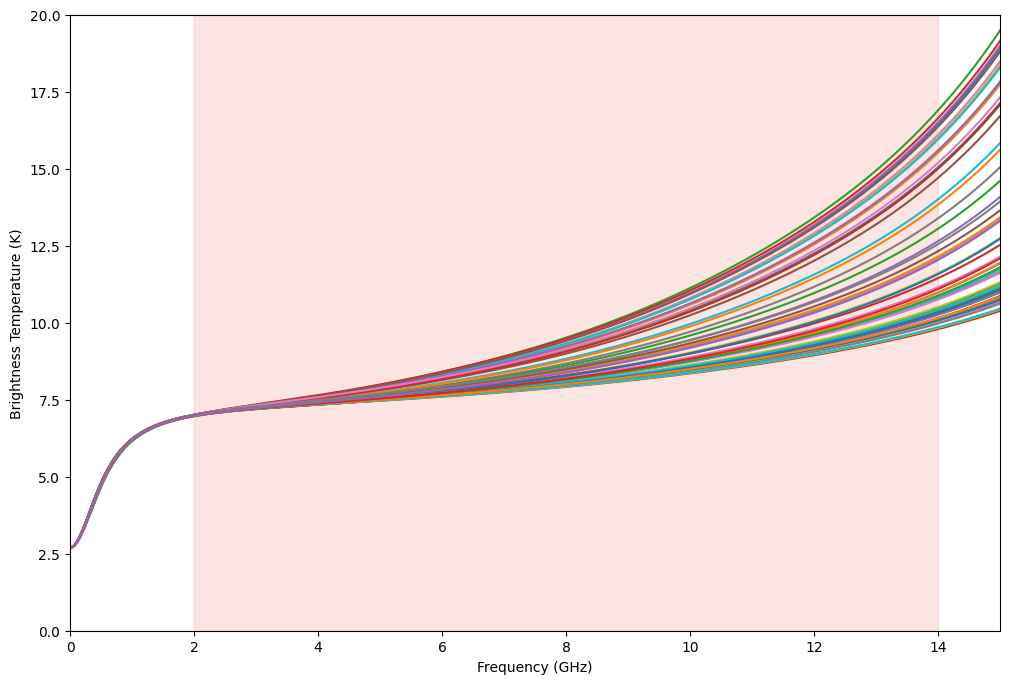

In [32]:
plt.figure(figsize=(12,8))
plt.axvspan(2, 14, color="#e74c3c", alpha=0.15, label="VGOS Broadband Track (2-14 GHz)")
plt.plot(frequency_axis,brightness[:,:])
plt.xlabel("Frequency (GHz)")
plt.ylabel("Brightness Temperature (K)")
plt.xlim(0,15)
plt.ylim(0,20)

Text(0, 0.5, 'Transmittance')

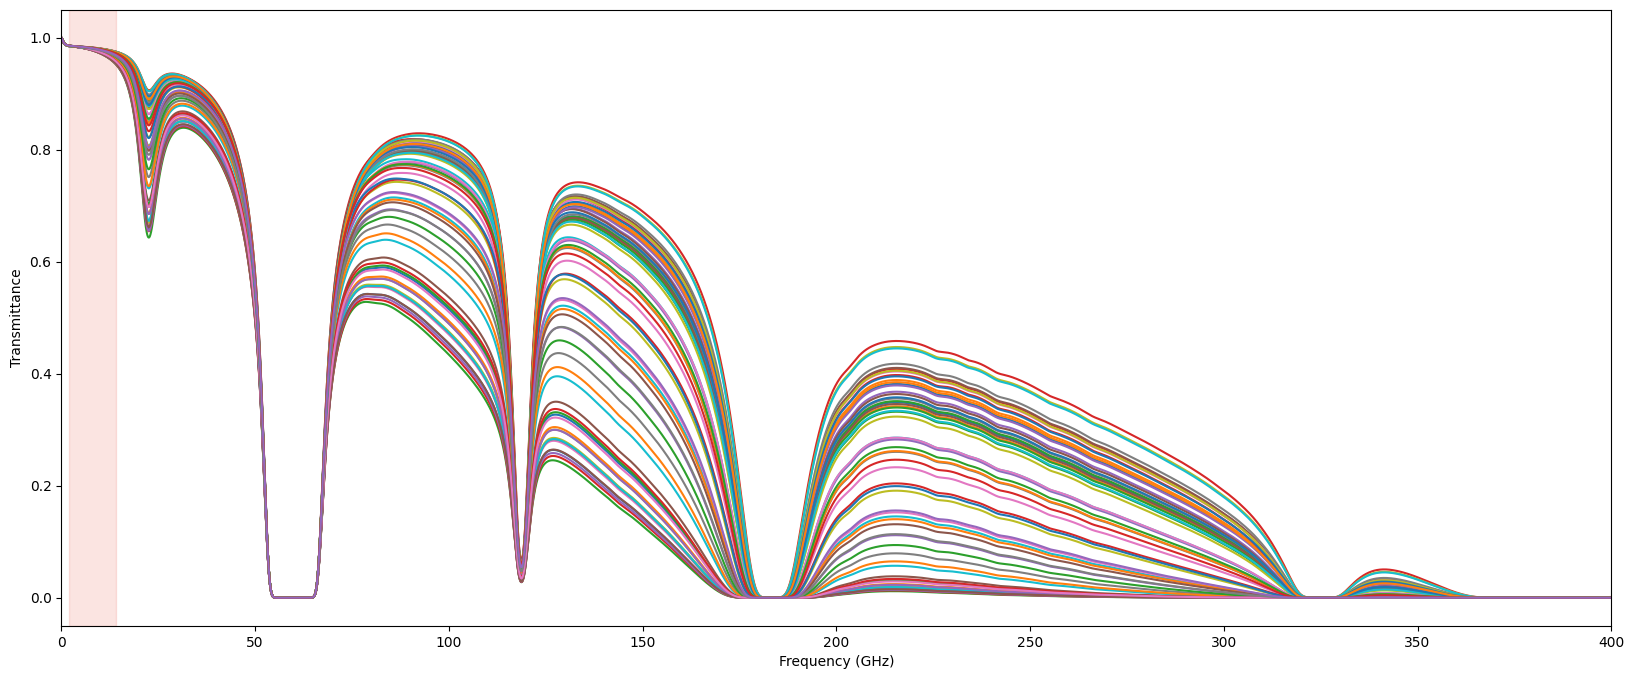

In [42]:
#plot
plt.figure(figsize=(20,8))
plt.axvspan(2, 14, color="#e74c3c", alpha=0.15, label="VGOS Broadband Track (2-14 GHz)")
plt.plot(frequency_axis,transmittance[:,:])
plt.xlim(0,400)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmittance")

Text(0, 0.5, 'Transmittance')

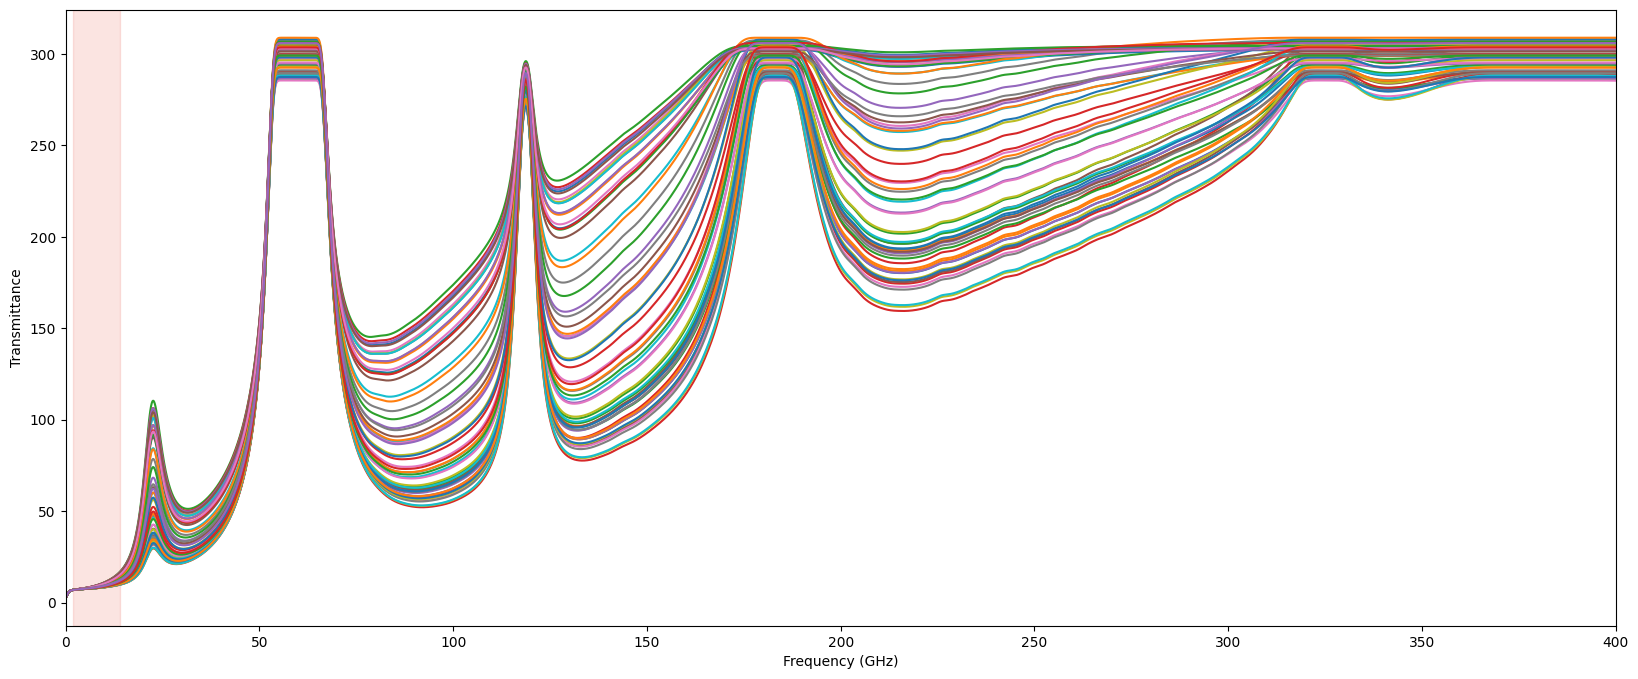

In [34]:
#plot
plt.figure(figsize=(20,8))
plt.axvspan(2, 14, color="#e74c3c", alpha=0.15, label="VGOS Broadband Track (2-14 GHz)")
plt.plot(frequency_axis,brightness[:,:])
plt.xlim(0,400)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmittance")

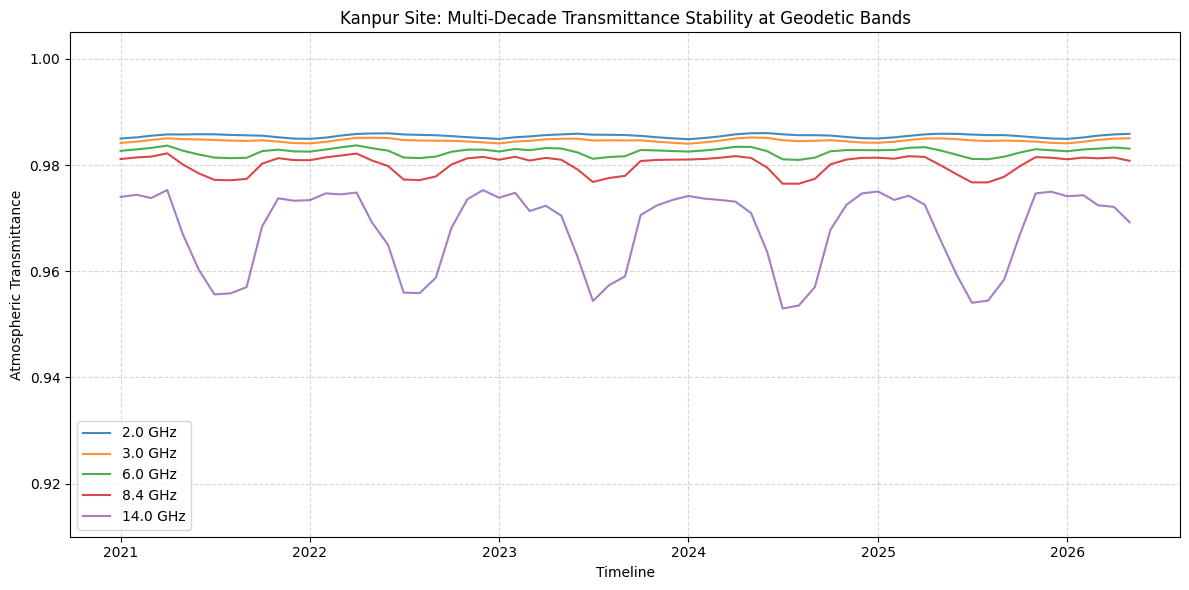

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Load matrices
freq = np.load("frequency_axis_ghz.npy")
transmittance = np.load("transmittance_history_matrix.npy")
# 'time' array from your notebook should still be in memory

# Target frequencies to evaluate
target_freqs = [2.0,3.0, 6.0, 8.4, 14.0]

plt.figure(figsize=(12, 6))
for f_target in target_freqs:
    # Find the closest matching index in your frequency axis
    idx = np.argmin(np.abs(freq - f_target))
    
    plt.plot(time, transmittance[idx, :], label=f'{f_target} GHz', alpha=0.85)

plt.ylim(0.91, 1.005)  # Zoom tightly into the top layer
plt.xlabel("Timeline")
plt.ylabel("Atmospheric Transmittance")
plt.title("Kanpur Site: Multi-Decade Transmittance Stability at Geodetic Bands")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

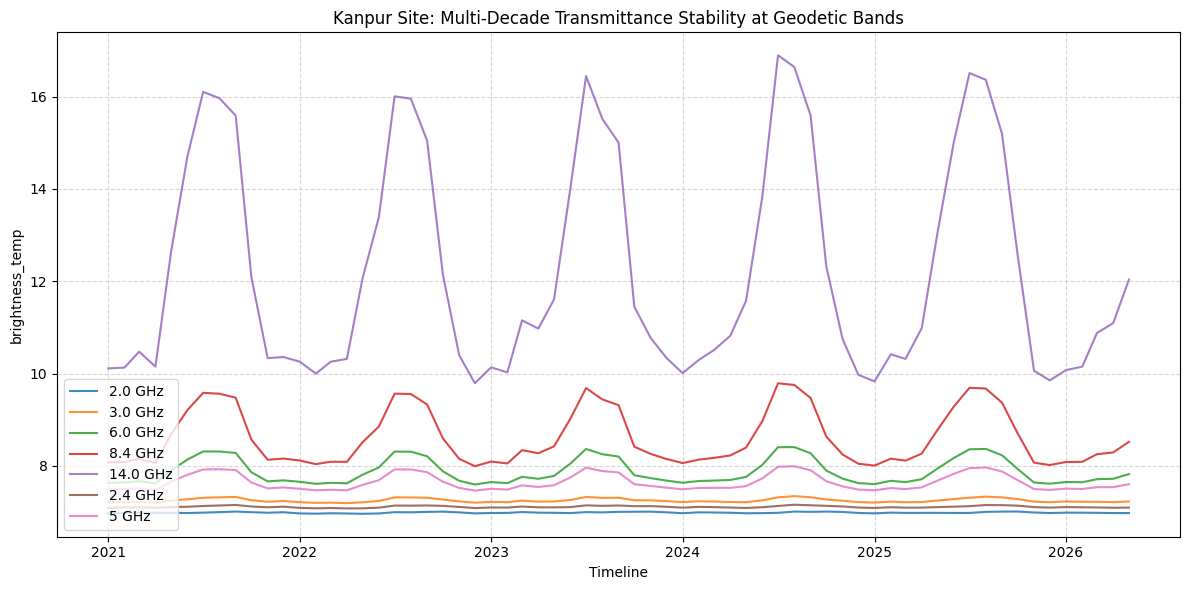

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load matrices
freq = np.load("frequency_axis_ghz.npy")
transmittance = np.load("brightness_temp_history_matrix.npy")
# 'time' array from your notebook should still be in memory

# Target frequencies to evaluate
target_freqs = [2.0,2.4,3.0, 6.0, 8.4, 14.0,5]

plt.figure(figsize=(12, 6))
for f_target in target_freqs:
    # Find the closest matching index in your frequency axis
    idx = np.argmin(np.abs(freq - f_target))
    
    plt.plot(time, transmittance[idx, :], label=f'{f_target} GHz', alpha=0.85)

  # Zoom tightly into the top layer
plt.xlabel("Timeline")
plt.ylabel("brightness_temp")
plt.title("Kanpur Site: Multi-Decade Transmittance Stability at Geodetic Bands")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:
file_ds_levels='monthlyaveragedpressurelevelthing.grib'
file_ds_sp=r'C:\Users\Darkrai\Projects\iitk proj\sp_tcwv\data.grib'

ds_levels=xr.open_dataset(file_ds_levels,engine='cfgrib')
ds_levels

<xarray.Dataset> Size: 89MB
Dimensions:        (time: 1037, isobaricInhPa: 37, latitude: 17, longitude: 17)
Coordinates:
    number         int64 8B ...
  * time           (time) datetime64[ns] 8kB 1940-01-01 ... 2026-05-01
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude       (latitude) float64 136B 28.5 28.25 28.0 ... 25.0 24.75 24.5
  * longitude      (longitude) float64 136B 78.5 78.75 79.0 ... 82.0 82.25 82.5
    valid_time     (time) datetime64[ns] 8kB ...
Data variables:
    z              (time, isobaricInhPa, latitude, longitude) float32 44MB ...
    q              (time, isobaricInhPa, latitude, longitude) float32 44MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-29T14:17 GRIB to CDM+CF via cfgrib-0.9.1...